**Segmentation using U-net**

# Connect google drive

In [1]:
# Connect google drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Define paths
# --- Define your paths ---
PATH_TO_X_TRAIN = '/content/drive/MyDrive/Aakash_RB_research/task_1_segmentation/Python_Script/Assets/images_train'
PATH_TO_Y_TRAIN = '/content/drive/MyDrive/Aakash_RB_research/task_1_segmentation/Python_Script/Assets/binary_masks_train'

PATH_TO_X_VAL = '/content/drive/MyDrive/Aakash_RB_research/task_1_segmentation/Python_Script/Assets/imges_val'
PATH_TO_Y_VAL = '/content/drive/MyDrive/Aakash_RB_research/task_1_segmentation/Python_Script/Assets/binary_mask_val'

model_save_path = '/content/drive/MyDrive/Aakash_RB_research/task_1_segmentation/Model_weights/segmentation_Unet_model.pth'

In [15]:
import matplotlib.pyplot as plt
from IPython.display import clear_output
from matplotlib.ticker import MaxNLocator
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader
import os
import cv2
import numpy as np
from skimage.color import rgb2lab

import torch.nn as nn
import torch.nn.functional as F

# Plot loss accuracy graph and dice-coefficient function

In [6]:
class PlotLossProgress:
  def __init__(self):
    self.epochs = []
    self.losses = []
    self.val_losses = []
    self.train_dice = []
    self.val_dice = []

  def update(self, epoch, train_loss, val_loss, train_dice, val_dice):
    self.epochs.append(epoch)
    self.losses.append(train_loss)
    self.val_losses.append(val_loss)
    self.train_dice.append(train_dice)
    self.val_dice.append(val_dice)

    # Clear the previous plot for live updating
    clear_output(wait=True)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # --- Plot 1: Loss ---
    ax1.plot(self.epochs, self.losses, label="Train Loss", marker='o', color='tab:blue')
    ax1.plot(self.epochs, self.val_losses, label="Validation Loss", marker='o', color='tab:orange')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss (MSE)')
    ax1.set_title('Training & Validation Loss')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))

    # --- Plot 2: Dice Accuracy ---
    ax2.plot(self.epochs, self.train_dice, label="Train Dice", marker='s', color='tab:green')
    ax2.plot(self.epochs, self.val_dice, label="Validation Dice", marker='s', color='tab:red')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Dice Coefficient')
    ax2.set_title('Segmentation Accuracy (Dice)')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.xaxis.set_major_locator(MaxNLocator(integer=True))

    plt.tight_layout()
    plt.show()

In [5]:
def get_dice_coefficient(outputs, targets, threshold=0.5):
    preds = (outputs > threshold).float()
    targets = (targets > threshold).float()
    smooth = 1e-6
    intersection = (preds * targets).sum(dim=(2, 3))
    union = preds.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))
    dice = (2. * intersection + smooth) / (union + smooth)
    return dice.mean().item()

# Custom Datagenerator

In [8]:
class SegmentationDataset(Dataset):
    def __init__(self, path_X, path_Y, image_size=256):
        self.path_X = path_X
        self.path_Y = path_Y
        self.image_size = image_size

        # 1. Get all input files (e.g., '010_2HC.png')
        # We use the filename without extension as the unique key
        self.files_x = {os.path.splitext(f)[0]: f for f in os.listdir(path_X)
                        if f.lower().endswith(('.png', '.jpg', '.jpeg'))}

        # 2. Get all mask files (e.g., '010_2HC_Annotation.png')
        # We strip '_Annotation' to see if it matches a key in files_x
        raw_masks = [f for f in os.listdir(path_Y) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        self.files_y = {}
        for f in raw_masks:
            name_without_ext = os.path.splitext(f)[0]
            # Remove the '_Annotation' suffix to get the matching ID
            match_id = name_without_ext.replace('_Annotation', '')
            self.files_y[match_id] = f

        # 3. Intersection: Only IDs that exist in both sets
        self.common_ids = sorted(list(set(self.files_x.keys()) & set(self.files_y.keys())))

        print(f"Match successful! Found {len(self.common_ids)} pairs.")
        if len(self.common_ids) > 0:
            print(f"Example Match: Input '{self.files_x[self.common_ids[0]]}' <---> Mask '{self.files_y[self.common_ids[0]]}'")

    def __len__(self):
        return len(self.common_ids)

    def _process_image(self, path):
        img = cv2.imread(path)
        if img is None: raise FileNotFoundError(f"Could not read {path}")
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_rgb = cv2.resize(img_rgb, (self.image_size, self.image_size))
        lab = rgb2lab(img_rgb).astype(np.float32)
        l_channel = lab[:, :, 0] / 100.0
        return torch.from_numpy(l_channel).float().unsqueeze(0)

    def __getitem__(self, index):
        sample_id = self.common_ids[index]
        X = self._process_image(os.path.join(self.path_X, self.files_x[sample_id]))
        Y = self._process_image(os.path.join(self.path_Y, self.files_y[sample_id]))
        return X, Y

# U-net model

In [10]:
class Unet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super(Unet, self).__init__()

        # Reduced dropout from 0.5 to 0.1/0.2 to help validation stability
        # Using Dropout2d is often better for spatial feature maps
        drop_rate = 0.1

        # --- ENCODER (Downsampling) ---
        self.conv1_1 = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.Dropout2d(drop_rate)
        )
        self.conv1_2 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.Dropout2d(drop_rate)
        )

        self.pool1 = nn.MaxPool2d(2)
        self.conv2_1 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.Dropout2d(drop_rate)
        )
        self.conv2_2 = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.Dropout2d(drop_rate)
        )

        self.pool2 = nn.MaxPool2d(2)
        self.conv3_1 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True), nn.Dropout2d(drop_rate)
        )
        self.conv3_2 = nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True), nn.Dropout2d(drop_rate)
        )

        self.pool3 = nn.MaxPool2d(2)
        self.conv4_1 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512), nn.ReLU(inplace=True), nn.Dropout2d(drop_rate)
        )
        self.conv4_2 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512), nn.ReLU(inplace=True), nn.Dropout2d(drop_rate)
        )

        self.pool4 = nn.MaxPool2d(2)
        self.conv5_1 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512), nn.ReLU(inplace=True), nn.Dropout2d(drop_rate)
        )
        self.conv5_2 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512), nn.ReLU(inplace=True), nn.Dropout2d(drop_rate)
        )

        # --- DECODER (Upsampling) ---
        self.upconv1 = nn.ConvTranspose2d(512, 512, kernel_size=2, stride=2)
        self.uconv1_1 = nn.Sequential(
            nn.Conv2d(1024, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True), nn.Dropout2d(drop_rate)
        )
        self.uconv1_2 = nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True), nn.Dropout2d(drop_rate)
        )

        self.upconv2 = nn.ConvTranspose2d(256, 256, kernel_size=2, stride=2)
        self.uconv2_1 = nn.Sequential(
            nn.Conv2d(512, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.Dropout2d(drop_rate)
        )
        self.uconv2_2 = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.Dropout2d(drop_rate)
        )

        self.upconv3 = nn.ConvTranspose2d(128, 128, kernel_size=2, stride=2)
        self.uconv3_1 = nn.Sequential(
            nn.Conv2d(256, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.Dropout2d(drop_rate)
        )
        self.uconv3_2 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.Dropout2d(drop_rate)
        )

        self.upconv4 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)
        self.uconv4_1 = nn.Sequential(
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.Dropout2d(drop_rate)
        )
        self.uconv4_2 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.Dropout2d(drop_rate)
        )

        # FINAL OUTPUT: Sigmoid forces values into [0, 1] range for segmentation
        self.final = nn.Sequential(
            nn.Conv2d(64, out_channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # Encoder
        xin = self.conv1_1(x)
        xin = self.conv1_2(xin) + xin

        xd1 = self.pool1(xin)
        xd1 = self.conv2_1(xd1)
        xd1 = self.conv2_2(xd1) + xd1

        xd2 = self.pool2(xd1)
        xd2 = self.conv3_1(xd2)
        xd2 = self.conv3_2(xd2) + xd2

        xd3 = self.pool3(xd2)
        xd3 = self.conv4_1(xd3)
        xd3 = self.conv4_2(xd3) + xd3

        xd4 = self.pool4(xd3)
        xd4 = self.conv5_1(xd4)
        xd4 = self.conv5_2(xd4) + xd4

        # Decoder
        xu1_up = self.upconv1(xd4)
        diffY, diffX = xd3.size()[2] - xu1_up.size()[2], xd3.size()[3] - xu1_up.size()[3]
        xu1_up = F.pad(xu1_up, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        xu1 = torch.cat([xd3, xu1_up], dim=1)
        xu1_pre = self.uconv1_1(xu1)
        xu1 = self.uconv1_2(xu1_pre) + xu1_pre

        xu2_up = self.upconv2(xu1)
        diffY, diffX = xd2.size()[2] - xu2_up.size()[2], xd2.size()[3] - xu2_up.size()[3]
        xu2_up = F.pad(xu2_up, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        xu2 = torch.cat([xd2, xu2_up], dim=1)
        xu2_pre = self.uconv2_1(xu2)
        xu2 = self.uconv2_2(xu2_pre) + xu2_pre

        xu3_up = self.upconv3(xu2)
        diffY, diffX = xd1.size()[2] - xu3_up.size()[2], xd1.size()[3] - xu3_up.size()[3]
        xu3_up = F.pad(xu3_up, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        xu3 = torch.cat([xd1, xu3_up], dim=1)
        xu3_pre = self.uconv3_1(xu3)
        xu3 = self.uconv3_2(xu3_pre) + xu3_pre

        xu4_up = self.upconv4(xu3)
        diffY, diffX = xin.size()[2] - xu4_up.size()[2], xin.size()[3] - xu4_up.size()[3]
        xu4_up = F.pad(xu4_up, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        xu4 = torch.cat([xin, xu4_up], dim=1)
        xu4_pre = self.uconv4_1(xu4)
        xu4 = self.uconv4_2(xu4_pre) + xu4_pre

        return self.final(xu4)

# Load Datagen and verify it

In [11]:
batch = 4

# --- Initialize the Datasets ---
train_dataset = SegmentationDataset(
    path_X=PATH_TO_X_TRAIN,
    path_Y=PATH_TO_Y_TRAIN,
    image_size=256
)

val_dataset = SegmentationDataset(
    path_X=PATH_TO_X_VAL,
    path_Y=PATH_TO_Y_VAL,
    image_size=256
)

# --- Initialize the DataLoaders ---
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch,
    shuffle=True,       # Shuffle training data to improve generalization
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch,       # Can be larger than training batch_size if memory allows
    shuffle=False,      # No need to shuffle validation data
    num_workers=4,
    pin_memory=True
)

Match successful! Found 422 pairs.
Example Match: Input '000_HC.png' <---> Mask '000_HC_Annotation.png'
Match successful! Found 200 pairs.
Example Match: Input '343_HC.png' <---> Mask '343_HC_Annotation.png'


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [13]:
X_train, Y_train = next(iter(train_loader))

print(f"Batch X_train Shape: {X_train.shape}")
print(f"Batch Y_train Shape: {Y_train.shape}")

Batch X_train Shape: torch.Size([4, 1, 256, 256])
Batch Y_train Shape: torch.Size([4, 1, 256, 256])


In [14]:
# Get one batch from the loader
X_test, Y_test = next(iter(train_loader))

print(f"Batch X_test Shape: {X_test.shape}")
# Expected: torch.Size([4, 1, 256, 256]) -> [Batch, Channel, Height, Width]

print(f"Batch Y_test Shape: {Y_test.shape}")
# Expected: torch.Size([4, 1, 256, 256]) -> [Batch, Channel, Height, Width]

Batch X_test Shape: torch.Size([4, 1, 256, 256])
Batch Y_test Shape: torch.Size([4, 1, 256, 256])


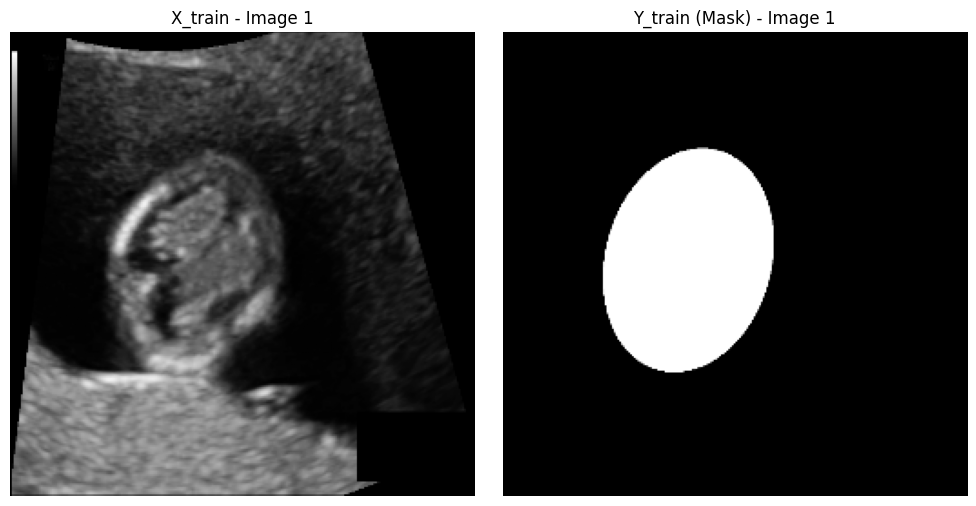

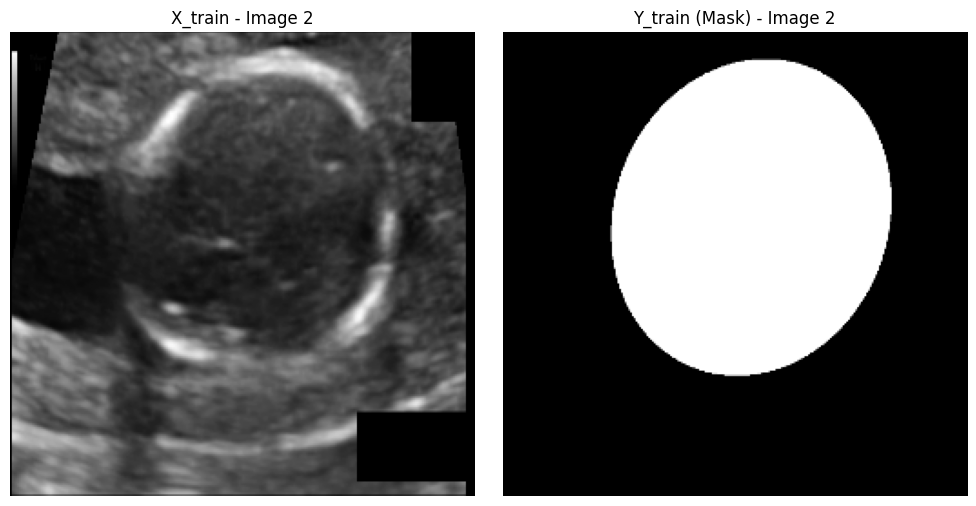

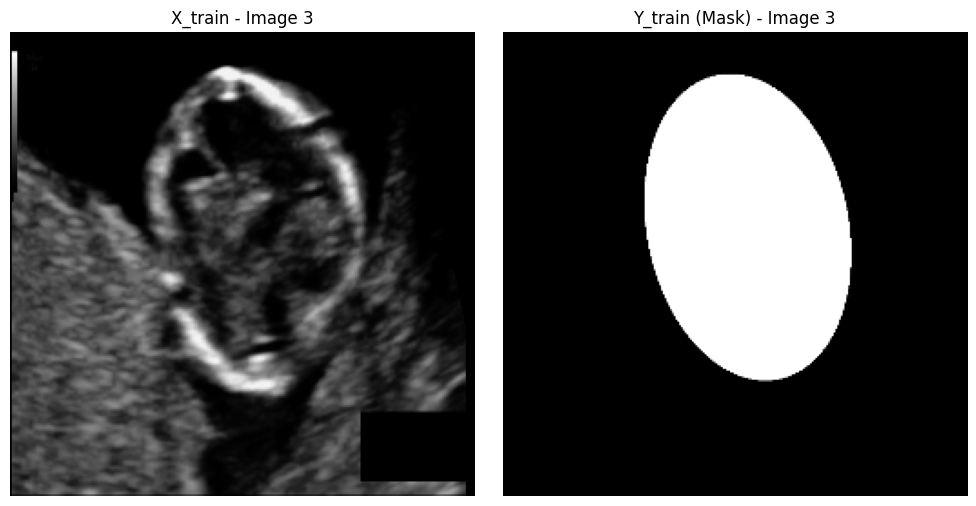

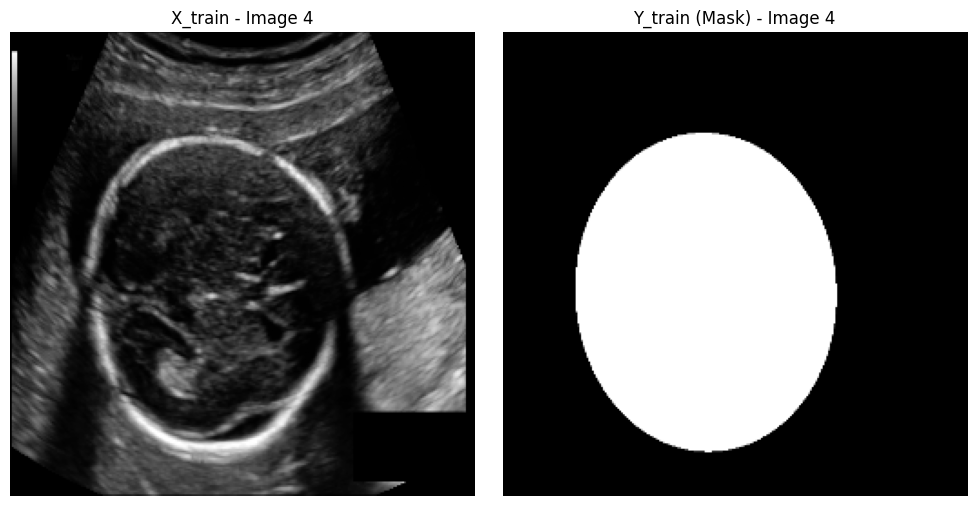

In [ ]:
# Assuming X_train and Y_train are already loaded from the previous cell
# X_train, Y_train = next(iter(train_loader))

num_images_to_display = X_train.shape[0] # Display all images in the batch

for i in range(num_images_to_display):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # Display X_train image
    x_img = X_train[i].squeeze().cpu().numpy() # Remove batch and channel dimensions, move to CPU, convert to numpy
    axes[0].imshow(x_img, cmap='gray')
    axes[0].set_title(f'X_train - Image {i+1}')
    axes[0].axis('off')

    # Display Y_train (mask) image
    y_img = Y_train[i].squeeze().cpu().numpy() # Remove batch and channel dimensions, move to CPU, convert to numpy
    axes[1].imshow(y_img, cmap='gray') # Masks are typically grayscale
    axes[1].set_title(f'Y_train (Mask) - Image {i+1}')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

Batch X_val Shape: torch.Size([4, 1, 256, 256])
Batch Y_val Shape: torch.Size([4, 1, 256, 256])


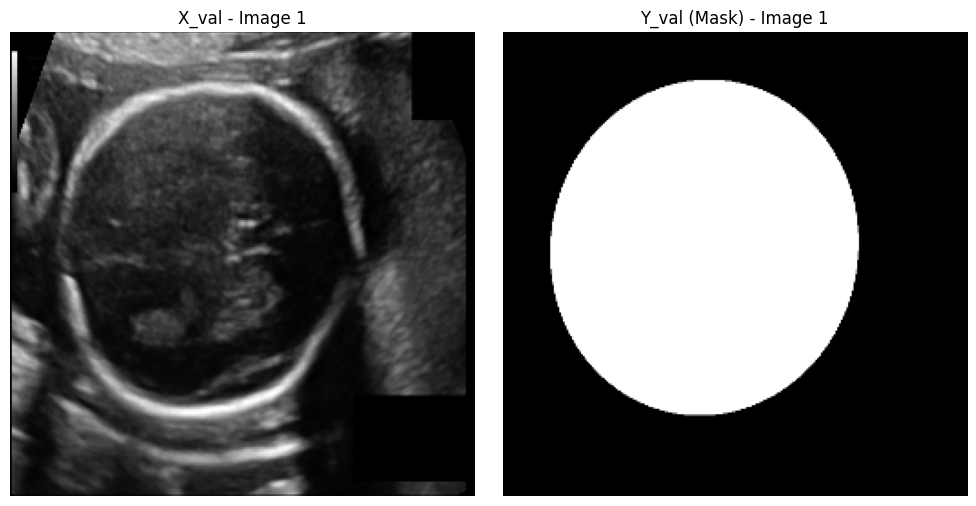

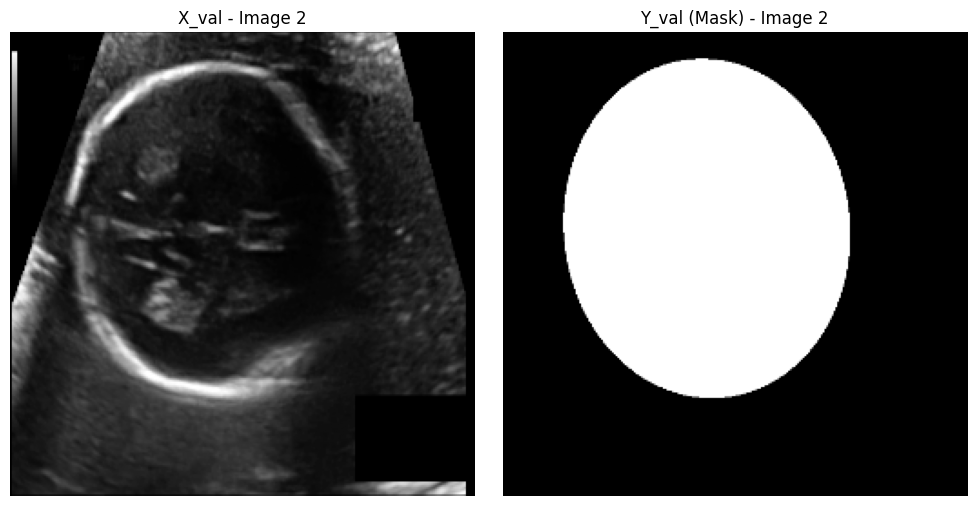

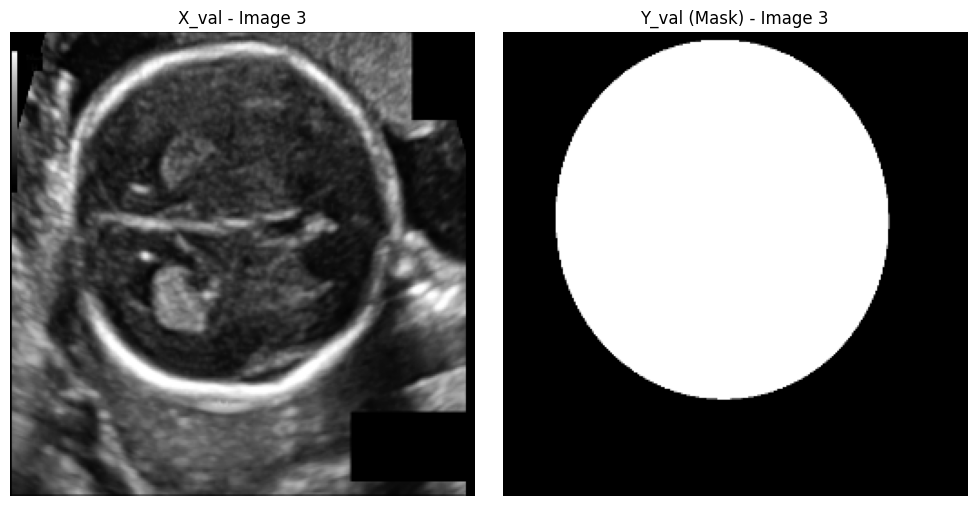

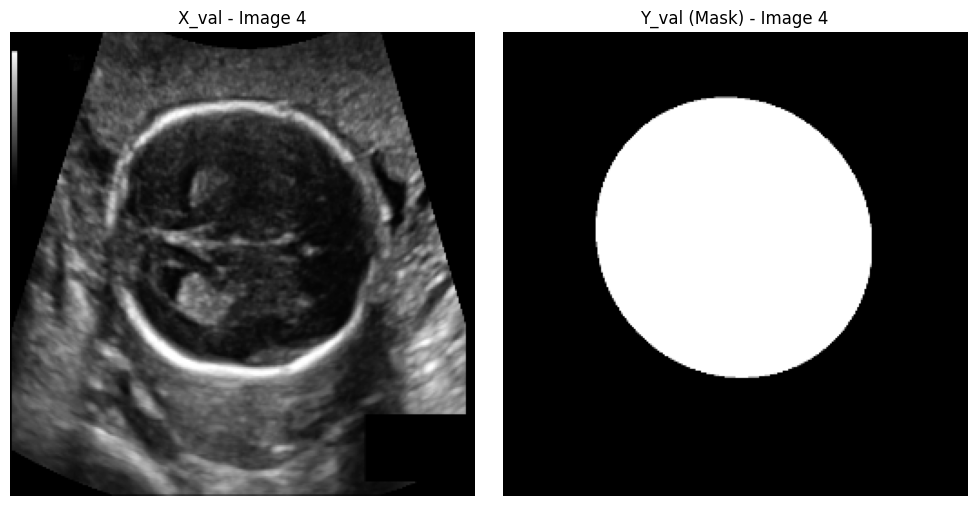

In [ ]:
# Get one batch from the validation loader
X_val, Y_val = next(iter(val_loader))

print(f"Batch X_val Shape: {X_val.shape}")
print(f"Batch Y_val Shape: {Y_val.shape}")

num_images_to_display = X_val.shape[0] # Display all images in the batch

for i in range(num_images_to_display):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # Display X_val image
    x_img = X_val[i].squeeze().cpu().numpy()
    axes[0].imshow(x_img, cmap='gray')
    axes[0].set_title(f'X_val - Image {i+1}')
    axes[0].axis('off')

    # Display Y_val (mask) image
    y_img = Y_val[i].squeeze().cpu().numpy()
    axes[1].imshow(y_img, cmap='gray') # Masks are typically grayscale
    axes[1].set_title(f'Y_val (Mask) - Image {i+1}')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

# Training the model

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Unet(in_channels=1, out_channels=1).to(device)
print(f"Using device: {device}")

Using device: cuda


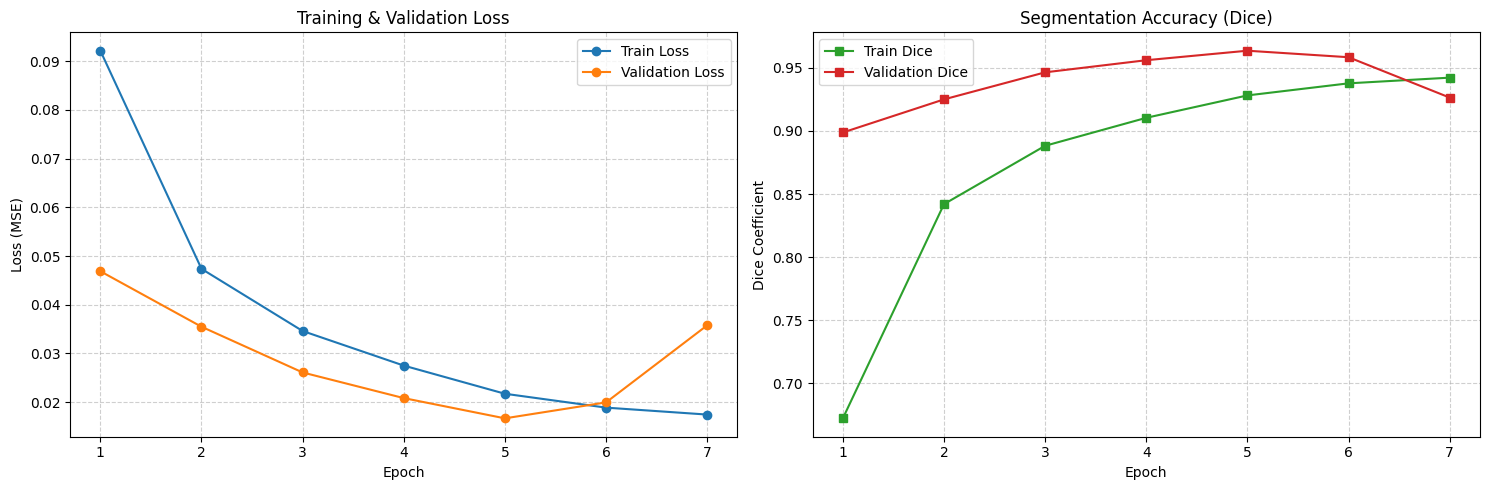

Training complete!


In [ ]:
import torch.optim as optim

# Define Optimizer and Loss Function
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss() # Mean Squared Error is a common choice for image regression tasks
num_epochs = 7
plot_progress = PlotLossProgress()

for epoch in range(num_epochs):
    # --- Training ---
    model.train()
    running_loss, running_dice = 0.0, 0.0
    for X_batch, Y_batch in train_loader:
        X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, Y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_dice += get_dice_coefficient(outputs, Y_batch)

    train_loss = running_loss / len(train_loader)
    train_dice = running_dice / len(train_loader)

    # --- Validation ---
    model.eval()
    val_running_loss, val_running_dice = 0.0, 0.0
    with torch.no_grad():
        for X_val_batch, Y_val_batch in val_loader:
            X_val_batch, Y_val_batch = X_val_batch.to(device), Y_val_batch.to(device)
            val_outputs = model(X_val_batch)

            v_loss = criterion(val_outputs, Y_val_batch)
            val_running_loss += v_loss.item()
            val_running_dice += get_dice_coefficient(val_outputs, Y_val_batch)

    val_loss_avg = val_running_loss / len(val_loader)
    val_dice_avg = val_running_dice / len(val_loader)

    # Update the live plot with all 4 metrics
    plot_progress.update(epoch + 1, train_loss, val_loss_avg, train_dice, val_dice_avg)

print("Training complete!")

# Saving the model

In [ ]:
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
}, model_save_path)

print(f"Model and optimizer states saved to {model_save_path}")

Model and optimizer states saved to /content/drive/MyDrive/Seg_collab/Seg_original/segmentation_Unet_model.pth
